## Importing all the essential Libraries

In [2]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Zomato-data- (11).csv")
df.head()
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


### Problem statement = Predict the rating of a restaurant based on features like online order availability, table booking option, number of votes, cost for two people, and restaurant type 

#### AND Analyze which factors affect reastaurent ratings
Gettting Rating on the basis of:
- online order availability, table booking option, number of votes, cost for two people, and restaurant type
  
And the research questions are:
- if customers are being able to order online, does it can increase ratings?
- Do more votes mean better ratings?
- Do expensive restaurants get better ratings?
- do most of customers are liking a specific restaurant type ?

## Data Overview 

In [3]:
df.shape

(148, 7)

In [23]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)', 'cost_category'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   name                         148 non-null    object  
 1   online_order                 148 non-null    object  
 2   book_table                   148 non-null    object  
 3   rate                         148 non-null    float64 
 4   votes                        148 non-null    int64   
 5   approx_cost(for two people)  148 non-null    int64   
 6   listed_in(type)              148 non-null    object  
 7   cost_category                148 non-null    category
dtypes: category(1), float64(1), int64(2), object(4)
memory usage: 8.6+ KB


In [11]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [10]:
df.describe(include = object)

,name,online_order,book_table,rate,listed_in(type)
count,148,148,148,148,148
unique,145,2,2,20,4
top,San Churro Cafe,No,No,3.8/5,Dining
freq,2,90,140,19,110


In [5]:
# rating column looks untidy removing /5 from it.

In [20]:
df['rate'] = df['rate'].str.replace('/5','')
df['rate'] = df['rate'].replace(['NEW','-'], None)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [32]:
df.rename(columns={'listed_in(type)':'restaurant_type'}, inplace=True)

In [7]:
df.isnull().sum();

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [9]:
# there is no null value in this dataset

# **DATA ANALYSIS AND VISUALISATION** 

# Bivariate Analysis

## Online ordering vs Rating:

In [13]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

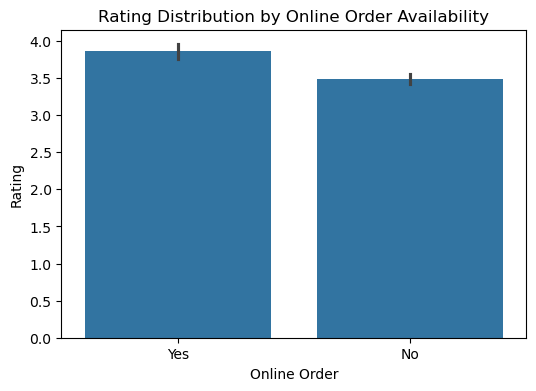

In [38]:
plt.figure(figsize=(6,4))
sns.barplot(x='online_order', y='rate', data=df)
plt.title("Rating Distribution by Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.show()

In [15]:
df['online_order'].value_counts(normalize=True) * 100

online_order
No     60.810811
Yes    39.189189
Name: proportion, dtype: float64

### Restaurants that allow online ordering have slightly higher average ratings, suggesting convenience may influence customer satisfaction.

## Booking availability vs Rating:

In [25]:
df['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

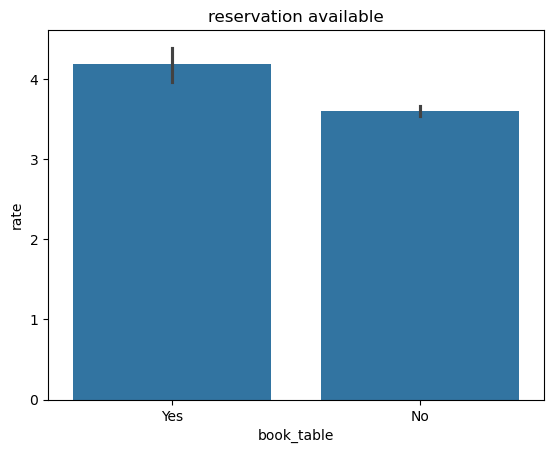

In [42]:
sns.barplot(x='book_table', y='rate', data=df)
plt.title("reservation available")
plt.show()

In [47]:
df.groupby('book_table')['rate'].agg(['count','mean'])

,count,mean
book_table,,
No,140,3.601429
Yes,8,4.187500


### Restaurants that allow table booking tend to have higher ratings. 

## Vote vs Rating:

In [57]:
df[['votes','rate']].corr()

,votes,rate
votes,1.000000,0.489844
rate,0.489844,1.000000


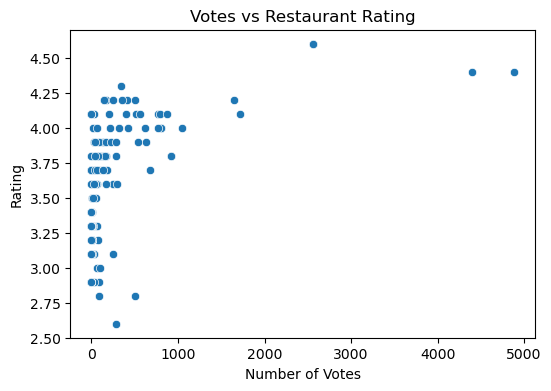

In [55]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='votes', y='rate', data=df)
plt.title("Votes vs Restaurant Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")
plt.show()

### The scatter plot shows a moderate positive relationship between number of votes and restaurant rating, suggesting that restaurants with more customer engagement(votes) tend to receive higher ratings.

More votes → higher rating

## Cost vs Rating:

In [43]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

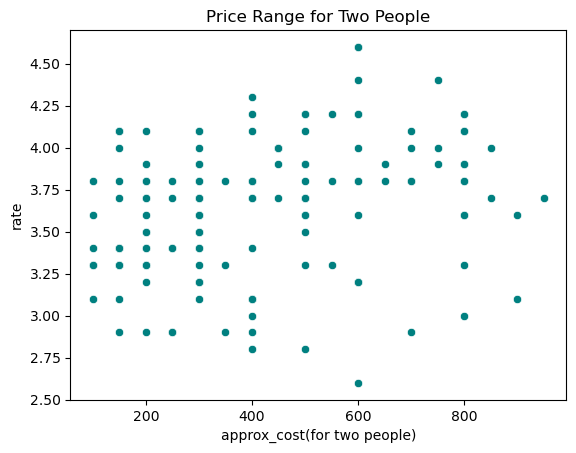

In [56]:
sns.scatterplot(x=df['approx_cost(for two people)'], y = df['rate'], color='teal')
plt.title('Price Range for Two People')
plt.show()

### Higher priced reastaurant tend to receive slightly better ratings , although the relationship between cost and ratings is not very strong.

## Restaurant type vs Rating:

In [58]:
df['restaurant_type'].value_counts()

restaurant_type
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

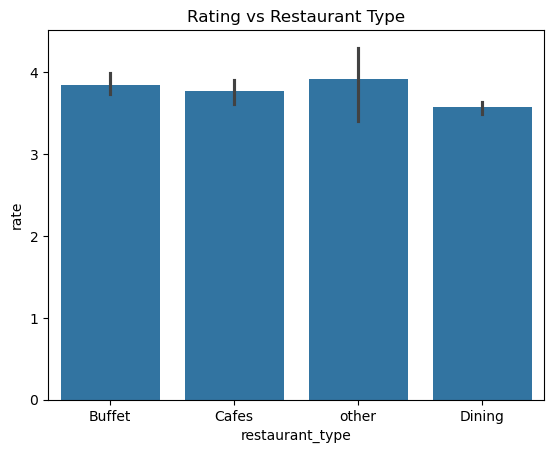

In [60]:
sns.barplot(x='restaurant_type', y='rate', data=df)
plt.title("Rating vs Restaurant Type")
plt.show()

### Restaurant rating across different restaurant types shows only small difference in average ratings. Indicating It does not strongly influence ratings.

In [72]:
top_ratings=df.sort_values('rate', ascending=False ).head(6)
top_ratings

,name,online_order,book_table,rate,votes,approx_cost(for two people),restaurant_type,cost_category
7,Onesta,Yes,Yes,4.6,2556,600.0,Cafes,Expensive
44,Onesta,Yes,Yes,4.6,2556,600.0,other,Expensive
38,Empire Restaurant,Yes,No,4.4,4884,750.0,other,Luxury
86,Meghana Foods,Yes,No,4.4,4401,600.0,Dining,Expensive
52,Corner House Ice Cream,No,No,4.3,345,400.0,Dining,Affordable
57,Wamama,Yes,Yes,4.2,354,800.0,other,Luxury


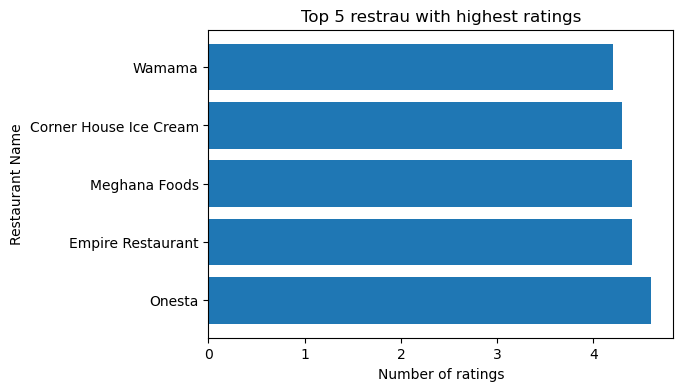

In [75]:
plt.figure(figsize=(6,4))
plt.barh(top_ratings['name'], top_ratings['rate'])
plt.xlabel("Number of ratings")
plt.ylabel("Restaurant Name")
plt.title("Top 5 restrau with highest ratings")
plt.show()

# **Report**

 Online ordering has a positive but small impact on ratings.

Reastaurants that allow table reservation tend to have better ratings.

popular Reastaurants tend to maintain higher ratings.

Price does not stringly determine ratings.

Reastaurants  type does not strongly affect ratings.


*Ratings plays a significant role in identifying successful restaurants, while service features such as online ordering can enhance customer engagement.*

*Overall, customer engagement and service features play a bigger role than pricing or restaurant category.*

## **Suggestions**
Restaurants should focus on improving service features like online ordering and table booking to enhance customer satisfaction. Increasing customer engagement and maintaining good service quality can help achieve higher ratings. Pricing alone may not improve ratings, so restaurants should prioritize customer experience and service efficiency.